# 03 — Portfolio Monte Carlo

10,000 paths, 70 trading days (≈ mid-July → mid-October). Model: GBM with **Student-t innovations (dof=4, fat tails)**, SPCX-GOOGL correlation ρ=0.45, **log-normal jump on the event day** (earnings + insider unlock, default -8% ± 12%). The spread has a mathematical hard cap: the test verifies it on every path.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, PALETTE
tufte_style()

In [2]:
from src.risk.montecarlo import McConfig, SpreadPosition, simulate, report
cfg, spread = McConfig(), SpreadPosition()
res = simulate(cfg, spread)
max_loss_spread = spread.debit * 100 * spread.contracts / 1.08
assert res["pnl_spread_eur"].min() >= -max_loss_spread - 1e-6, "HARD CAP VIOLATED"
rep = report(res)
pd.Series(rep).round(1)

mean              73.0
median            86.4
VaR95            320.5
ES95             392.1
p_loss             0.4
p_loss_gt_200      0.1
best_5pct        448.5
worst_path      -633.7
dtype: float64

## Total P&L distribution with VaR/ES annotated

The chart Aladdin shows for every book: not a number, the **shape** of the risk. Short right tail (gain capped by the spread), long left tail (the equity tranche has no hard cap).

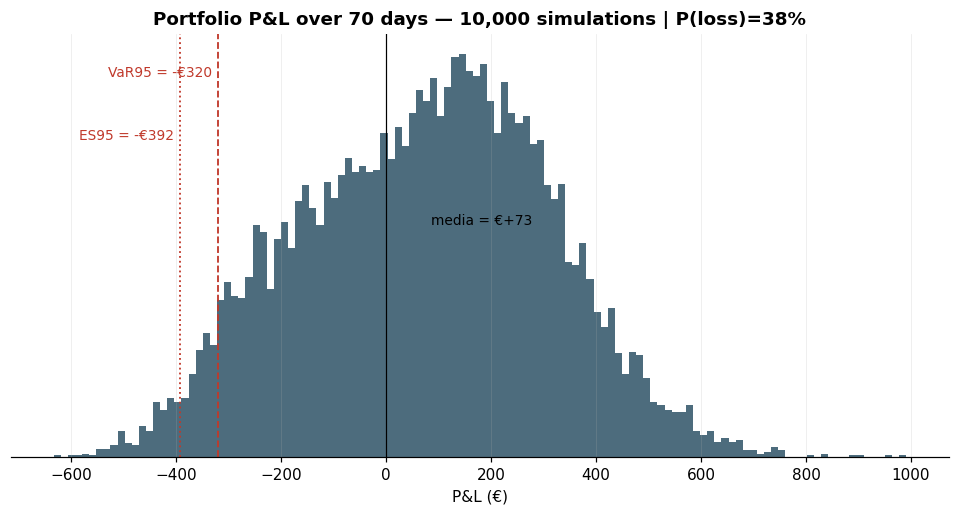

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
pnl_distribution(ax, res["pnl_total_eur"], rep["VaR95"], rep["ES95"],
                 f"Portfolio P&L over 70 days — 10,000 simulations | P(loss)={rep['p_loss']:.0%}")
fig.savefig("../assets/chart_mc_pnl.png", bbox_inches="tight"); plt.show()

## Spread payoff at expiry + where the simulated paths land

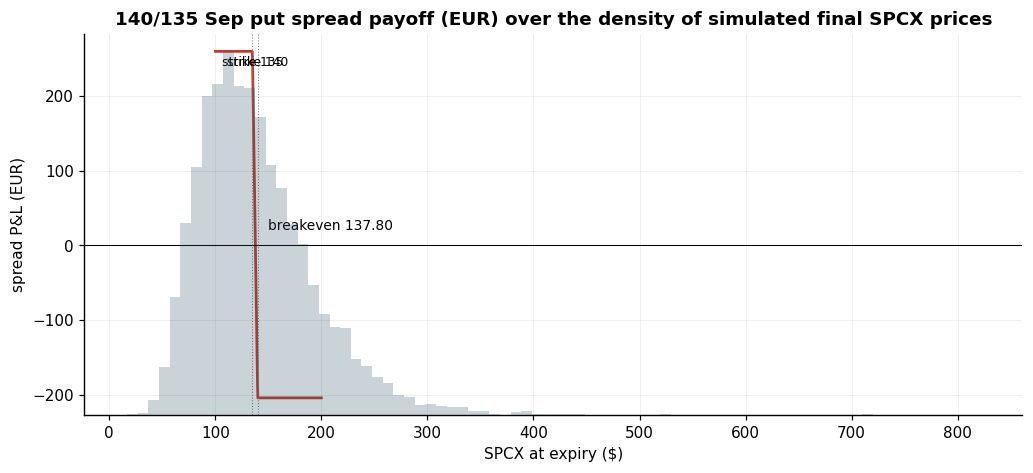

In [4]:
grid = np.linspace(100, 200, 300)
payoff_eur = spread.payoff(grid) / 1.08
fig, ax = plt.subplots(figsize=(11, 4.5))
ax2 = ax.twinx()
ax2.hist(res["spcx_final"], bins=80, color=PALETTE[0], alpha=0.25)
ax2.set_yticks([]); ax2.spines["right"].set_visible(False)
ax.plot(grid, payoff_eur, lw=1.8, color=PALETTE[1])
ax.axhline(0, color="black", lw=0.7)
for s, lbl in [(spread.short_strike, "strike 135"), (spread.long_strike, "strike 140")]:
    ax.axvline(s, color="gray", lw=0.7, ls=":")
    ax.annotate(lbl, (s, ax.get_ylim()[1]*0.85), fontsize=8, ha="center")
be = spread.long_strike - spread.debit
ax.annotate(f"breakeven {be:.2f}", (be, 0), xytext=(8, 10), textcoords="offset points", fontsize=9)
ax.set_title("140/135 Sep put spread payoff (EUR) over the density of simulated final SPCX prices")
ax.set_xlabel("SPCX at expiry ($)"); ax.set_ylabel("spread P&L (EUR)")
fig.savefig("../assets/chart_payoff.png", bbox_inches="tight"); plt.show()

## Sensitivity: mean P&L as a function of the event jump

The backbone of the decision: the strategy lives or dies on the size of the August jump. Everything else is noise.

In [5]:
from dataclasses import replace
rows = []
for jm in [-0.20, -0.15, -0.10, -0.08, -0.05, 0.0, 0.05]:
    r = report(simulate(replace(cfg, jump_mean=jm, seed=11), spread))
    rows.append({"event_jump": f"{jm:+.0%}", "mean P&L": round(r["mean"]), "P(loss)": f"{r['p_loss']:.0%}", "VaR95": round(r["VaR95"]), "ES95": round(r["ES95"])})
sens = pd.DataFrame(rows).set_index("event_jump")
sens

,mean P&L,P(loss),VaR95,ES95
event_jump,,,,
-20%,127,28%,274,347
-15%,102,32%,295,367
-10%,78,37%,313,385
-8%,68,39%,321,393
-5%,53,42%,331,401
+0%,31,45%,345,414
+5%,9,50%,356,425


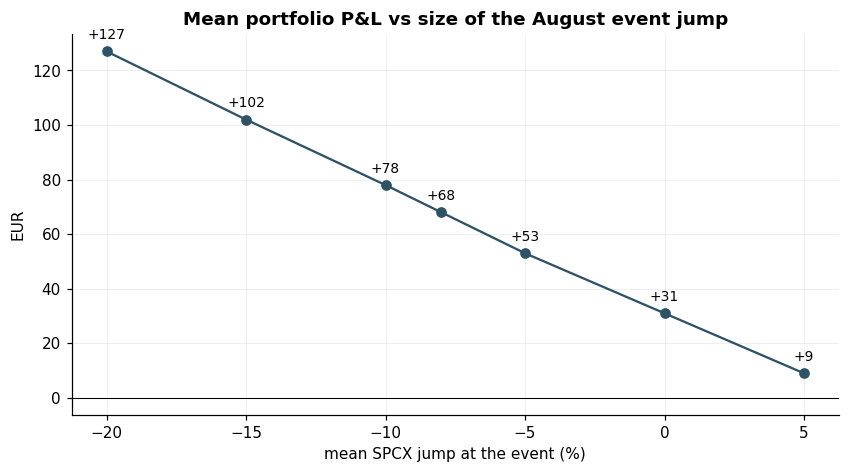

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = [-20, -15, -10, -8, -5, 0, 5]
y = sens["mean P&L"].values
ax.plot(x, y, marker="o", lw=1.5)
ax.axhline(0, color="black", lw=0.7)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:+.0f}", (xi, yi), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax.set_title("Mean portfolio P&L vs size of the August event jump")
ax.set_xlabel("mean SPCX jump at the event (%)"); ax.set_ylabel("EUR")
fig.savefig("../assets/chart_sensitivity.png", bbox_inches="tight"); plt.show()

## Operational conclusions

1. The spread hard cap holds on 10,000 paths: losses beyond the structural cap come only from the equity tranche (market beta), never from the derivative.
2. Positive EV requires an event jump ≤ -5%: consistent with the analytical breakeven probability (P≥44%).
3. The left tail (ES95) is dominated by the equity tranche: to shrink it, cut equity, not the spread.
4. **Update parameters with real data** once SPCX trades: `spcx_s0`, `spcx_vol` (from listed-option IV), real `debit`.